Directorio: /home/coders/Escritorio/emausoft-analytics
Leyendo desde cache: /home/coders/Escritorio/emausoft-analytics/data/interim/paises.csv
Shape paises: (250, 7)
               pais iso2 iso3   region        subregion        lat         lng
0       Ivory Coast   CI  CIV   Africa   Western Africa   8.000000   -5.000000
1             Italy   IT  ITA   Europe  Southern Europe  42.833333   12.833333
2        Kyrgyzstan   KG  KGZ     Asia     Central Asia  41.000000   75.000000
3  Papua New Guinea   PG  PNG  Oceania        Melanesia  -6.000000  147.000000
4              Fiji   FJ  FJI  Oceania        Melanesia -17.713400  178.065000

Nulos:
pais         0
iso2         1
iso3         0
region       0
subregion    5
lat          0
lng          0
dtype: int64

Regiones unicas:
region
Africa       59
Americas     56
Europe       53
Asia         50
Oceania      27
Antarctic     5
Name: count, dtype: int64


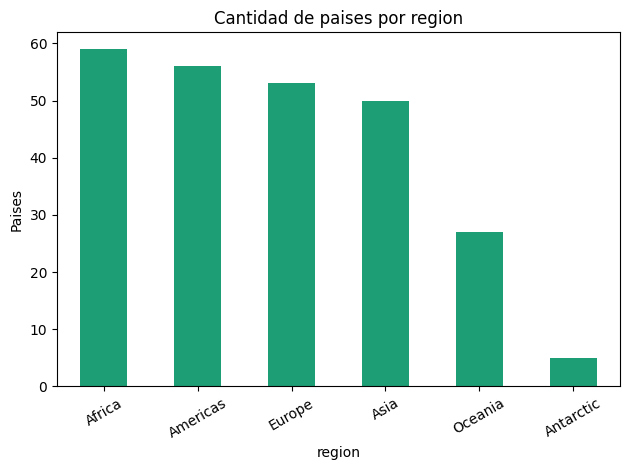

Todos los paises encontraron match

Columnas despues del enriquecimiento:
['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER', 'SALES', 'ORDERDATE', 'STATUS', 'QTR_ID', 'MONTH_ID', 'YEAR_ID', 'PRODUCTLINE', 'MSRP', 'PRODUCTCODE', 'CUSTOMERNAME', 'PHONE', 'ADDRESSLINE1', 'ADDRESSLINE2', 'CITY', 'STATE', 'POSTALCODE', 'COUNTRY', 'TERRITORY', 'CONTACTLASTNAME', 'CONTACTFIRSTNAME', 'DEALSIZE', 'cliente_id', 'pais_norm', 'pais', 'iso2', 'iso3', 'region', 'subregion', 'lat', 'lng']


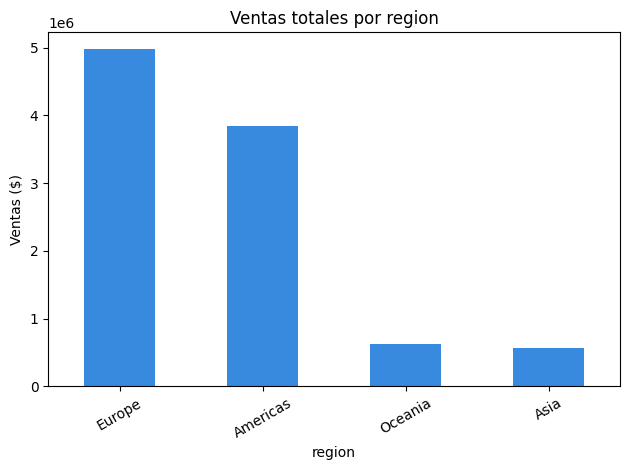


Ventas por region:
region
Europe      4979272.41
Americas    3852061.39
Oceania      630623.10
Asia         570671.95
Name: SALES, dtype: float64


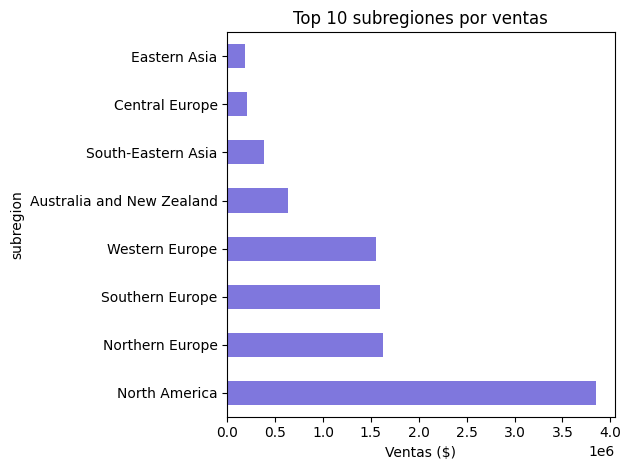

Guardado: data/interim/ventas_enriquecida.csv


In [1]:
import os, sys, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

ROOT = Path('/home/coders/Escritorio/emausoft-analytics')
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
print(f'Directorio: {os.getcwd()}')

from src.ingestion.fetch_paises import fetch_paises, enriquecer_ventas

# Carga de paises

df_paises = fetch_paises()
print(f'Shape paises: {df_paises.shape}')
print(df_paises.head())

# Limpieza basica

print('\nNulos:')
print(df_paises.isnull().sum())
print('\nRegiones unicas:')
print(df_paises['region'].value_counts())

# Grafico de regiones

df_paises['region'].value_counts().plot(kind='bar', color='#1D9E75')
plt.title('Cantidad de paises por region')
plt.ylabel('Paises')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Enriquecimiento de ventas

df_ventas = pd.read_csv(ROOT / 'data/interim/ventas_con_cliente.csv')
df_enriquecido = enriquecer_ventas(df_ventas, df_paises)

print(f'\nColumnas despues del enriquecimiento:')
print(df_enriquecido.columns.tolist())
# Ventas por region
ventas_region = (df_enriquecido
    .groupby('region')['SALES']
    .sum()
    .sort_values(ascending=False))

ventas_region.plot(kind='bar', color='#378ADD')
plt.title('Ventas totales por region')
plt.ylabel('Ventas ($)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print('\nVentas por region:')
print(ventas_region)
# Ventas por subregion

ventas_sub = (df_enriquecido
    .groupby('subregion')['SALES']
    .sum()
    .sort_values(ascending=False)
    .head(10))

ventas_sub.plot(kind='barh', color='#7F77DD')
plt.title('Top 10 subregiones por ventas')
plt.xlabel('Ventas ($)')
plt.tight_layout()
plt.show()
#   Ventas por pais

df_enriquecido.to_csv(ROOT / 'data/interim/ventas_enriquecida.csv', index=False)
print('Guardado: data/interim/ventas_enriquecida.csv')